# Heart Failure Survival Analysis (Simulated Dataset)

Exploratory survival analysis of simulated heart failure outcomes using Kaplan-Meier curves and log-rank testing.

**Author:** Andre Moises Nunes, MD


## Objective

To practice Python-based cardiovascular outcomes analysis by comparing simulated survival outcomes between groups stratified by ejection fraction.

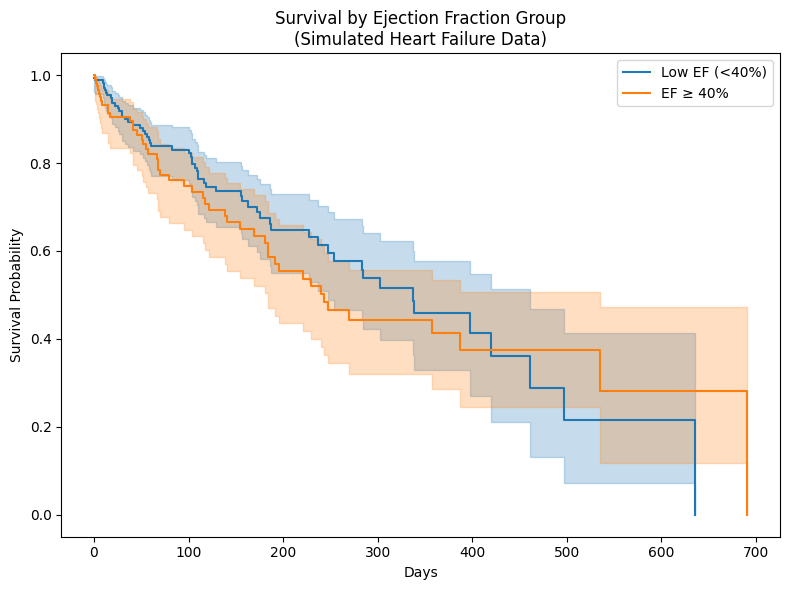

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Criar dataset sintético com estrutura idêntica ao original
np.random.seed(42)
n = 299
df = pd.DataFrame({
    'time': np.random.exponential(150, n).astype(int),
    'death_event': np.random.binomial(1, 0.35, n),
    'ejection_fraction': np.random.normal(38, 12, n)
})
df['ejection_fraction'] = df['ejection_fraction'].clip(14, 80)
df['low_ef'] = df['ejection_fraction'] < 40

# Resto do código permanece igual ao original
plt.figure(figsize=(8,6))
ax = plt.subplot()

kmf_low = KaplanMeierFitter()
kmf_low.fit(durations=df[df['low_ef']==True]['time'],
            event_observed=df[df['low_ef']==True]['death_event'],
            label='Low EF (<40%)')
kmf_low.plot(ax=ax, ci_show=True)

kmf_preserved = KaplanMeierFitter()
kmf_preserved.fit(durations=df[df['low_ef']==False]['time'],
                  event_observed=df[df['low_ef']==False]['death_event'],
                  label='EF ≥ 40%')
kmf_preserved.plot(ax=ax, ci_show=True)

plt.title('Survival by Ejection Fraction Group\n(Simulated Heart Failure Data)')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.legend()
plt.tight_layout()
plt.show()

results = logrank_test(
    durations_A=df[df['low_ef']==True]['time'],
    durations_B=df[df['low_ef']==False]['time'],
    event_observed_A=df[df['low_ef']==True]['death_event'],
    event_observed_B=df[df['low_ef']==False]['death_event']
)
results.print_summary()

## Results

The Kaplan-Meier curves did not show a statistically significant survival difference between simulated groups stratified by ejection fraction.

The log-rank test result was p = 0.52.

Because this dataset was synthetically generated for educational purposes, these results should be interpreted as a demonstration of the analytical workflow rather than as a clinical finding.

## Tools Used

- Python
- Pandas
- NumPy
- Lifelines
- Matplotlib
- Google Colab

In [ ]:
!pip install lifelines
